# SHAP Explainability and Risk Framework 

In [4]:
# 1. Imports and environment check

import sys
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    SHAP_AVAILABLE = False
    SHAP_IMPORT_ERROR = exc

print("Python executable:", sys.executable)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("SHAP available:", SHAP_AVAILABLE)

if not SHAP_AVAILABLE:
    print("SHAP import error:", SHAP_IMPORT_ERROR)
    print("Install with: %pip install shap")

Python executable: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\.venv\Scripts\python.exe
pandas: 2.2.2
numpy: 1.26.4
SHAP available: True


In [5]:
# 2. Define project paths

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
SPLIT_DATA_DIR = PROCESSED_DATA_DIR / "splits"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_PREDICTIONS_DIR = PROJECT_ROOT / "outputs" / "predictions"
MODELS_DIR = PROJECT_ROOT / "models"
SHAP_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "shap"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
SHAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("SHAP output folder:", SHAP_OUTPUT_DIR)

Project root: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter
SHAP output folder: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\outputs\shap


In [6]:
# 3. Load only lightweight outputs

required_paths = {
    "best_model_selection": OUTPUT_TABLES_DIR / "best_model_selection_from_validation.csv",
    "selected_thresholds": OUTPUT_TABLES_DIR / "selected_thresholds_from_validation.csv",
    "test_event_results": OUTPUT_TABLES_DIR / "test_event_level_results_selected_thresholds.csv",
    "test_predictions": OUTPUT_PREDICTIONS_DIR / "test_predictions_selected_thresholds.csv",
    "X_test": SPLIT_DATA_DIR / "X_test_12h.csv",
    "feature_mapping": OUTPUT_TABLES_DIR / "model_feature_name_mapping.csv"
}

missing = [name for name, path in required_paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing required files from previous steps: {missing}")

best_model_selection = pd.read_csv(required_paths["best_model_selection"])
selected_thresholds = pd.read_csv(required_paths["selected_thresholds"])
test_event_results = pd.read_csv(required_paths["test_event_results"])
test_predictions = pd.read_csv(required_paths["test_predictions"])
feature_mapping = pd.read_csv(required_paths["feature_mapping"])

test_predictions["timestamp"] = pd.to_datetime(test_predictions["timestamp"], errors="coerce")
test_predictions = test_predictions.dropna(subset=["timestamp"]).reset_index(drop=True)

print("Best model selection:")
display(best_model_selection)

print("\nTest predictions shape:", test_predictions.shape)
print("Test prediction period:", test_predictions["timestamp"].min(), "to", test_predictions["timestamp"].max())

Best model selection:


,score_column,model,threshold,precision,recall,f1,f2,pr_auc,roc_auc,true_negative,...,max_lead_time_hours,total_alarm_episodes,true_alarm_episodes,false_alarm_episodes,false_alarm_episodes_per_day,total_alarm_time_hours,median_alarm_duration_minutes,max_alarm_duration_minutes,alert_episode_precision,selection_note
0,logistic_regression_score,Logistic Regression,0.05,0.019876,1.0,0.038978,0.092061,0.011186,0.305266,43711,...,11.998333,59,1,58,1.443239,620.975833,266.283333,5787.8,0.016949,No threshold met <=1 false alarm episode/day; ...



Test predictions shape: (348590, 16)
Test prediction period: 2020-07-15 02:30:07 to 2020-09-01 03:59:50


In [7]:
# 4. Select model for SHAP explanation

best_overall_model = best_model_selection["model"].iloc[0]
best_overall_threshold = float(best_model_selection["threshold"].iloc[0])
best_overall_score_col = best_model_selection["score_column"].iloc[0]

supervised_models = ["Logistic Regression", "Random Forest", "XGBoost"]

if best_overall_model in supervised_models:
    explanation_model_name = best_overall_model
    explanation_threshold = best_overall_threshold
    explanation_score_col = best_overall_score_col
else:
    supervised_candidates = selected_thresholds[selected_thresholds["model"].isin(supervised_models)].copy()
    if supervised_candidates.empty:
        raise ValueError("No supervised model available for SHAP explanation.")
    supervised_candidates = supervised_candidates.sort_values(
        by=["f2", "failure_detection_rate", "median_lead_time_hours", "pr_auc"],
        ascending=[False, False, False, False]
    )
    explanation_model_name = supervised_candidates["model"].iloc[0]
    explanation_threshold = float(supervised_candidates["threshold"].iloc[0])
    explanation_score_col = supervised_candidates["score_column"].iloc[0]

print("Best overall model:", best_overall_model)
print("Best overall threshold:", best_overall_threshold)
print("Model used for SHAP explanation:", explanation_model_name)
print("Explanation score column:", explanation_score_col)
print("Explanation threshold:", explanation_threshold)

Best overall model: Logistic Regression
Best overall threshold: 0.05
Model used for SHAP explanation: Logistic Regression
Explanation score column: logistic_regression_score
Explanation threshold: 0.05


In [8]:
# 5. Load trained model and feature mapping

model_file_map = {
    "Logistic Regression": MODELS_DIR / "logistic_regression_model.joblib",
    "Random Forest": MODELS_DIR / "random_forest_model.joblib",
    "XGBoost": MODELS_DIR / "xgboost_model.joblib"
}

model_path = model_file_map.get(explanation_model_name)

if model_path is None or not model_path.exists():
    raise FileNotFoundError(f"Model file not found for {explanation_model_name}: {model_path}")

model_pipeline = joblib.load(model_path)

original_feature_names = feature_mapping["original_feature_name"].tolist()
safe_feature_names = feature_mapping["safe_feature_name"].tolist()

print("Loaded model:", explanation_model_name)
print("Feature count:", len(safe_feature_names))

Loaded model: Logistic Regression
Feature count: 115


In [9]:
# 6. Create representative SHAP sample indices without loading full X_test

MAX_SHAP_ROWS = 500
RANDOM_STATE = 42

working = test_predictions.copy()
score_col = explanation_score_col
pred_col = f"{explanation_model_name.lower().replace(' ', '_')}_selected_prediction"

if pred_col not in working.columns:
    working[pred_col] = (working[score_col] >= explanation_threshold).astype(int)

working["case_type"] = "true_negative"
working.loc[(working["y_true"] == 1) & (working[pred_col] == 1), "case_type"] = "true_positive"
working.loc[(working["y_true"] == 0) & (working[pred_col] == 1), "case_type"] = "false_positive"
working.loc[(working["y_true"] == 1) & (working[pred_col] == 0), "case_type"] = "false_negative"

sample_indices = []

for case_type, max_n in [
    ("true_positive", 100),
    ("false_positive", 100),
    ("false_negative", 100),
    ("true_negative", 200)
]:
    idx = working[working["case_type"] == case_type].index
    if len(idx) > 0:
        sampled_idx = pd.Series(idx).sample(
            n=min(max_n, len(idx)),
            random_state=RANDOM_STATE
        ).tolist()
        sample_indices.extend(sampled_idx)

sample_indices = sorted(list(set(sample_indices)))

if len(sample_indices) > MAX_SHAP_ROWS:
    sample_indices = sorted(
        pd.Series(sample_indices).sample(n=MAX_SHAP_ROWS, random_state=RANDOM_STATE).tolist()
    )

shap_metadata = working.iloc[sample_indices].copy()

print("SHAP sample rows:", len(sample_indices))
print("Case type distribution:")
print(shap_metadata["case_type"].value_counts())

SHAP sample rows: 400
Case type distribution:
case_type
true_negative     200
false_negative    100
false_positive    100
Name: count, dtype: int64


In [10]:
# 7. Load only selected X_test rows using chunks

def load_selected_rows_from_csv(csv_path, selected_indices, usecols=None, chunksize=50_000):
    selected_set = set(selected_indices)
    selected_sorted = sorted(selected_indices)
    collected = []
    start_row = 0

    for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=chunksize):
        end_row = start_row + len(chunk)
        local_positions = [
            global_idx - start_row
            for global_idx in selected_sorted
            if start_row <= global_idx < end_row
        ]

        if local_positions:
            temp = chunk.iloc[local_positions].copy()
            temp["__row_id__"] = [start_row + pos for pos in local_positions]
            collected.append(temp)

        start_row = end_row

        if start_row > max(selected_set):
            break

    if not collected:
        raise ValueError("No selected rows were loaded from X_test CSV.")

    output = pd.concat(collected, ignore_index=True)
    output = output.sort_values("__row_id__").reset_index(drop=True)
    output = output.drop(columns=["__row_id__"])

    return output

X_test_sample_original = load_selected_rows_from_csv(
    required_paths["X_test"],
    selected_indices=sample_indices,
    usecols=original_feature_names,
    chunksize=50_000
)

X_shap = X_test_sample_original.copy()
X_shap.columns = safe_feature_names

for col in X_shap.columns:
    X_shap[col] = pd.to_numeric(X_shap[col], errors="coerce")

X_shap = X_shap.replace([np.inf, -np.inf], np.nan).astype("float32")

print("Loaded X_shap shape:", X_shap.shape)

Loaded X_shap shape: (400, 115)


In [11]:
# 8. Calculate SHAP values

if not SHAP_AVAILABLE:
    raise ImportError("SHAP is not installed. Run: %pip install shap")

if explanation_model_name == "Logistic Regression":
    imputer = model_pipeline.named_steps["imputer"]
    scaler = model_pipeline.named_steps["scaler"]
    estimator = model_pipeline.named_steps["model"]

    X_imp = imputer.transform(X_shap)
    X_transformed = scaler.transform(X_imp)
    feature_names_for_shap = safe_feature_names

    explainer = shap.LinearExplainer(estimator, X_transformed)
    shap_values_raw = explainer.shap_values(X_transformed)

elif explanation_model_name in ["Random Forest", "XGBoost"]:
    imputer = model_pipeline.named_steps["imputer"]
    estimator = model_pipeline.named_steps["model"]

    X_transformed = imputer.transform(X_shap)
    feature_names_for_shap = safe_feature_names

    explainer = shap.TreeExplainer(estimator)
    shap_values_raw = explainer.shap_values(X_transformed)

    if isinstance(shap_values_raw, list):
        shap_values_raw = shap_values_raw[1]

else:
    raise ValueError(f"Unsupported explanation model for SHAP: {explanation_model_name}")

shap_values = np.asarray(shap_values_raw)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

print("SHAP values shape:", shap_values.shape)
print("Transformed X shape:", X_transformed.shape)

SHAP values shape: (400, 115)
Transformed X shape: (400, 115)


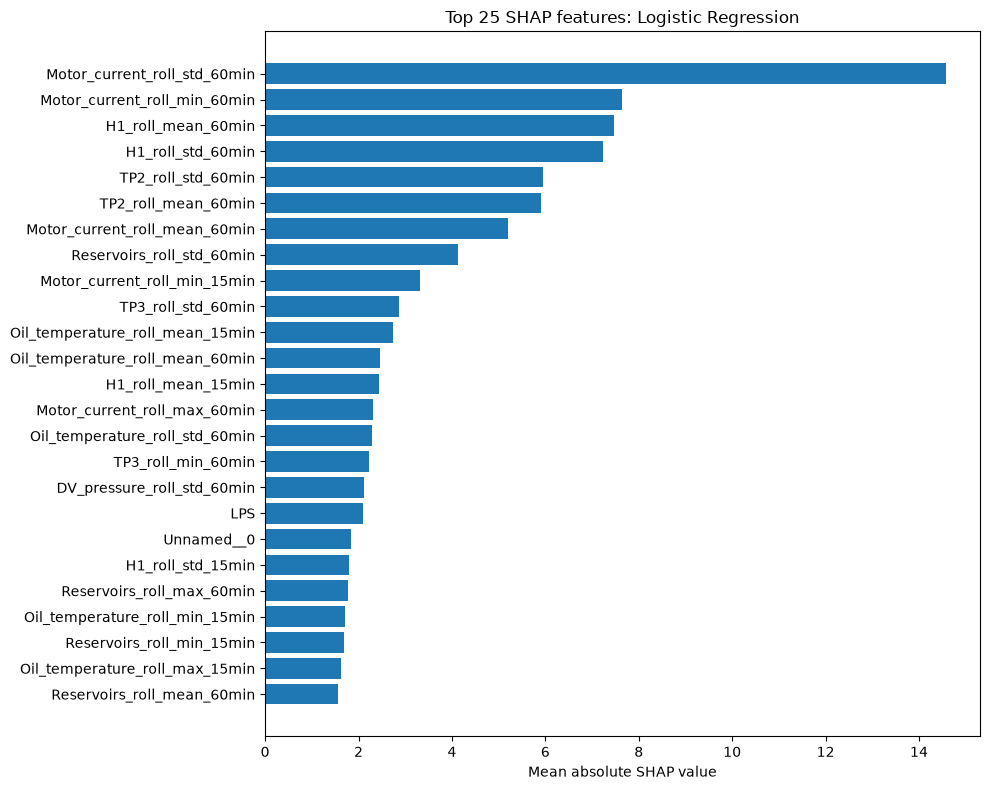

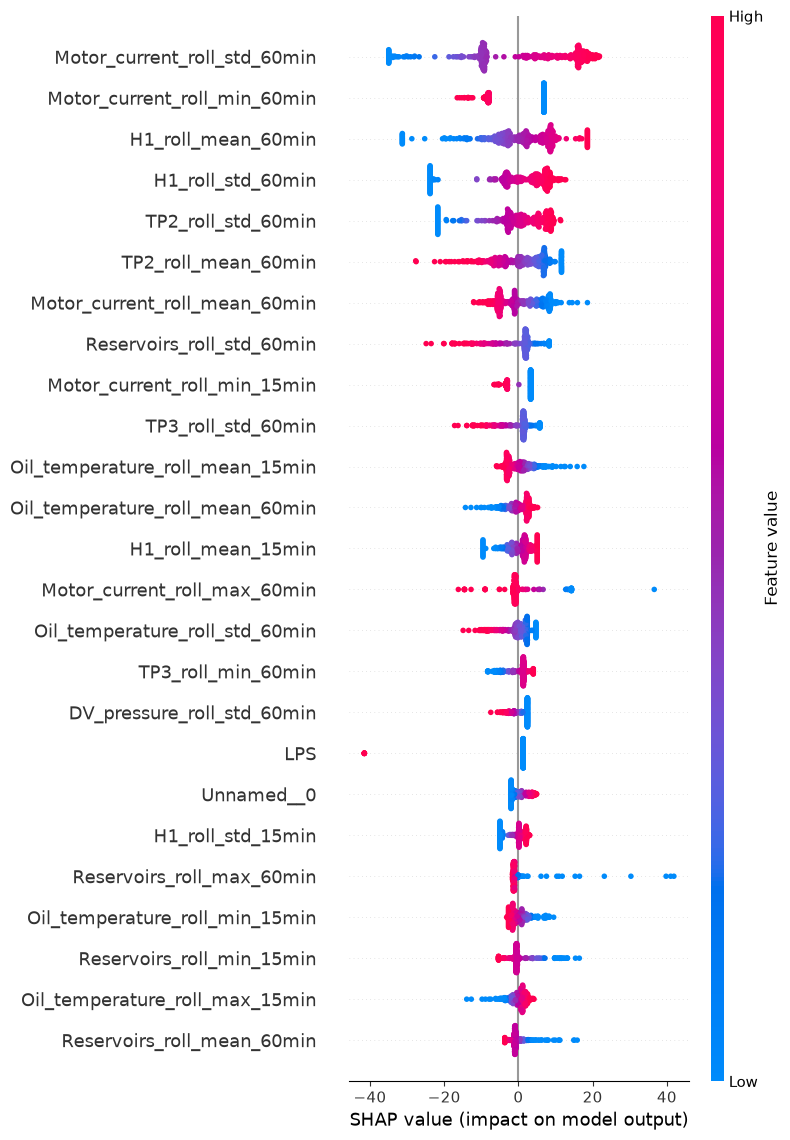

,feature,mean_absolute_shap
72,Motor_current_roll_std_60min,14.576353
73,Motor_current_roll_min_60min,7.638772
39,H1_roll_mean_60min,7.469849
40,H1_roll_std_60min,7.239104
24,TP2_roll_std_60min,5.946291
23,TP2_roll_mean_60min,5.909609
71,Motor_current_roll_mean_60min,5.193528
56,Reservoirs_roll_std_60min,4.133220
69,Motor_current_roll_min_15min,3.315463
32,TP3_roll_std_60min,2.858460


In [12]:
# 9. Global SHAP importance and plots

mean_abs_shap = np.abs(shap_values).mean(axis=0)

global_shap_importance = pd.DataFrame({
    "feature": feature_names_for_shap,
    "mean_absolute_shap": mean_abs_shap
}).sort_values("mean_absolute_shap", ascending=False)

global_shap_importance.to_csv(SHAP_OUTPUT_DIR / "global_shap_feature_importance.csv", index=False)
global_shap_importance.to_csv(OUTPUT_TABLES_DIR / "global_shap_feature_importance.csv", index=False)

top_n = 25
top_shap = global_shap_importance.head(top_n).sort_values("mean_absolute_shap", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_shap["feature"], top_shap["mean_absolute_shap"])
plt.xlabel("Mean absolute SHAP value")
plt.title(f"Top {top_n} SHAP features: {explanation_model_name}")
plt.tight_layout()
plt.savefig(SHAP_OUTPUT_DIR / "global_shap_top_features.png", dpi=300)
plt.savefig(OUTPUT_FIGURES_DIR / "global_shap_top_features.png", dpi=300)
plt.show()

try:
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_transformed,
        feature_names=feature_names_for_shap,
        show=False,
        max_display=25
    )
    plt.tight_layout()
    plt.savefig(SHAP_OUTPUT_DIR / "shap_summary_plot.png", dpi=300, bbox_inches="tight")
    plt.savefig(OUTPUT_FIGURES_DIR / "shap_summary_plot.png", dpi=300, bbox_inches="tight")
    plt.show()
except Exception as exc:
    print("SHAP summary plot could not be created:", exc)

global_shap_importance.head(20)

In [13]:
# 10. Local explanations for representative TP, FP and FN cases

local_records = []

for case_type in ["true_positive", "false_positive", "false_negative"]:
    case_rows = shap_metadata[shap_metadata["case_type"] == case_type]

    if case_rows.empty:
        continue

    if case_type in ["true_positive", "false_positive"]:
        selected_index = case_rows[score_col].idxmax()
    else:
        selected_index = case_rows[score_col].idxmin()

    sample_position = shap_metadata.index.get_loc(selected_index)
    row_shap = shap_values[sample_position]
    abs_order = np.argsort(np.abs(row_shap))[::-1][:10]

    for rank, feature_idx in enumerate(abs_order, start=1):
        local_records.append({
            "case_type": case_type,
            "timestamp": shap_metadata.loc[selected_index, "timestamp"],
            "y_true": int(shap_metadata.loc[selected_index, "y_true"]),
            "prediction": int(shap_metadata.loc[selected_index, pred_col]),
            "risk_score": float(shap_metadata.loc[selected_index, score_col]),
            "rank": rank,
            "feature": feature_names_for_shap[feature_idx],
            "shap_value": float(row_shap[feature_idx]),
            "absolute_shap_value": float(abs(row_shap[feature_idx]))
        })

local_explanations = pd.DataFrame(local_records)
local_explanations.to_csv(SHAP_OUTPUT_DIR / "local_shap_case_explanations.csv", index=False)
local_explanations.to_csv(OUTPUT_TABLES_DIR / "local_shap_case_explanations.csv", index=False)

local_explanations.head(30)

,case_type,timestamp,y_true,prediction,risk_score,rank,feature,shap_value,absolute_shap_value
0,false_positive,2020-08-30 05:02:11,0,1,1.000000e+00,1,Motor_current_roll_std_60min,17.301275,17.301275
1,false_positive,2020-08-30 05:02:11,0,1,1.000000e+00,2,H1_roll_mean_60min,9.198857,9.198857
2,false_positive,2020-08-30 05:02:11,0,1,1.000000e+00,3,Motor_current_roll_mean_60min,7.483964,7.483964
3,false_positive,2020-08-30 05:02:11,0,1,1.000000e+00,4,TP2_roll_mean_60min,6.906506,6.906506
4,false_positive,2020-08-30 05:02:11,0,1,1.000000e+00,5,Motor_current_roll_min_60min,6.858876,6.858876
5,false_positive,2020-08-30 05:02:11,0,1,1.000000e+00,6,Unnamed__0,4.627584,4.627584
6,false_positive,2020-08-30 05:02:11,0,1,1.000000e+00,7,Oil_temperature_roll_mean_60min,-3.815304,3.815304
7,false_positive,2020-08-30 05:02:11,0,1,1.000000e+00,8,Oil_temperature_roll_mean_15min,3.690161,3.690161
8,false_positive,2020-08-30 05:02:11,0,1,1.000000e+00,9,Motor_current_roll_min_15min,3.299269,3.299269
9,false_positive,2020-08-30 05:02:11,0,1,1.000000e+00,10,H1_roll_std_60min,-3.123939,3.123939


In [14]:
# 11. Risk-level framework

def assign_risk_level(score, threshold):
    if score < 0.25 * threshold:
        return "Normal"
    elif score < 0.50 * threshold:
        return "Low"
    elif score < threshold:
        return "Medium"
    elif score < min(1.0, threshold * 1.50):
        return "High"
    else:
        return "Critical"

risk_action_map = {
    "Normal": "Continue normal operation. No immediate maintenance action required.",
    "Low": "Continue operation and monitor trend during routine review.",
    "Medium": "Increase monitoring and inspect related sensor trends if the pattern continues.",
    "High": "Prioritise maintenance inspection and review compressor pressure, temperature and current behaviour.",
    "Critical": "Treat as urgent warning. Escalate for immediate engineering review before continued operation."
}

risk_framework_table = pd.DataFrame({
    "risk_level": list(risk_action_map.keys()),
    "prototype_rule": [
        "score < 0.25 × selected threshold",
        "0.25 × threshold ≤ score < 0.50 × threshold",
        "0.50 × threshold ≤ score < selected threshold",
        "selected threshold ≤ score < 1.50 × threshold",
        "score ≥ 1.50 × threshold, capped at 1.0"
    ],
    "recommended_action": list(risk_action_map.values()),
    "important_note": ["Research prototype only; not an operational railway maintenance rule."] * len(risk_action_map)
})

risk_framework_table.to_csv(OUTPUT_TABLES_DIR / "risk_framework_rules.csv", index=False)
risk_framework_table

,risk_level,prototype_rule,recommended_action,important_note
0,Normal,score < 0.25 × selected threshold,Continue normal operation. No immediate mainte...,Research prototype only; not an operational ra...
1,Low,0.25 × threshold ≤ score < 0.50 × threshold,Continue operation and monitor trend during ro...,Research prototype only; not an operational ra...
2,Medium,0.50 × threshold ≤ score < selected threshold,Increase monitoring and inspect related sensor...,Research prototype only; not an operational ra...
3,High,selected threshold ≤ score < 1.50 × threshold,Prioritise maintenance inspection and review c...,Research prototype only; not an operational ra...
4,Critical,"score ≥ 1.50 × threshold, capped at 1.0",Treat as urgent warning. Escalate for immediat...,Research prototype only; not an operational ra...


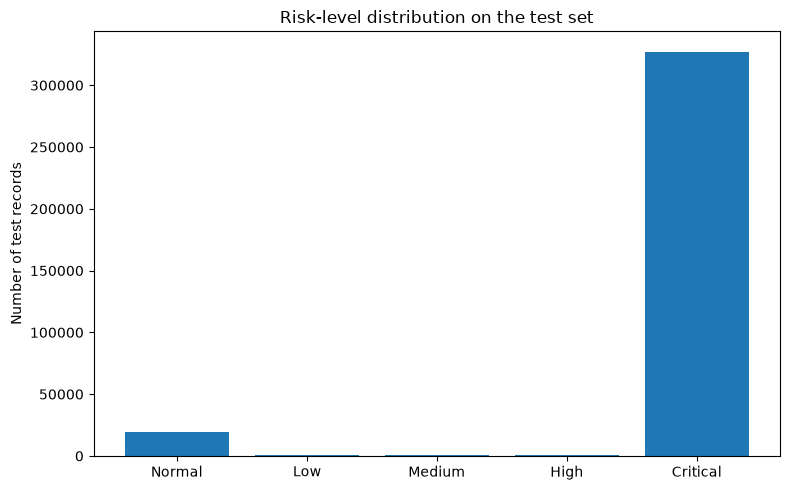

,risk_level,count,percentage
0,Critical,327266,93.882785
1,Normal,19525,5.601136
2,Medium,700,0.200809
3,High,550,0.157778
4,Low,549,0.157492


In [15]:
# 12. Final risk predictions using test prediction file only

risk_predictions = test_predictions.copy()

risk_predictions["selected_model"] = best_overall_model
risk_predictions["selected_threshold"] = best_overall_threshold
risk_predictions["risk_score"] = risk_predictions[best_overall_score_col]
risk_predictions["risk_level"] = risk_predictions["risk_score"].apply(
    lambda x: assign_risk_level(x, best_overall_threshold)
)
risk_predictions["recommended_action"] = risk_predictions["risk_level"].map(risk_action_map)

selected_pred_col = f"{best_overall_model.lower().replace(' ', '_')}_selected_prediction"

if selected_pred_col not in risk_predictions.columns:
    risk_predictions[selected_pred_col] = (
        risk_predictions["risk_score"] >= best_overall_threshold
    ).astype(int)

risk_predictions["alarm_flag"] = risk_predictions[selected_pred_col]

risk_predictions_path = OUTPUT_PREDICTIONS_DIR / "final_risk_predictions_test_set.csv"
risk_predictions.to_csv(risk_predictions_path, index=False, chunksize=100_000)

high_risk_predictions = risk_predictions[
    risk_predictions["risk_level"].isin(["High", "Critical"])
].copy()

high_risk_predictions.to_csv(
    OUTPUT_TABLES_DIR / "high_critical_risk_predictions_test_set.csv",
    index=False
)

risk_distribution = risk_predictions["risk_level"].value_counts().reset_index()
risk_distribution.columns = ["risk_level", "count"]
risk_distribution["percentage"] = risk_distribution["count"] / len(risk_predictions) * 100

risk_distribution.to_csv(OUTPUT_TABLES_DIR / "risk_level_distribution_test_set.csv", index=False)

order = ["Normal", "Low", "Medium", "High", "Critical"]
plot_data = risk_distribution.set_index("risk_level").reindex(order).fillna(0).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(plot_data["risk_level"], plot_data["count"])
plt.ylabel("Number of test records")
plt.title("Risk-level distribution on the test set")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "risk_level_distribution_test_set.png", dpi=300)
plt.show()

risk_distribution

In [16]:
# 13. Final framework summary and checklist

top_10_features = global_shap_importance.head(10)["feature"].tolist()

framework_summary = pd.DataFrame({
    "item": [
        "Best overall model from validation",
        "Best overall threshold",
        "Model explained using SHAP",
        "SHAP sample size",
        "Top 10 SHAP features",
        "Risk levels created",
        "High/Critical test records",
        "Risk framework status",
        "Important limitation"
    ],
    "value": [
        best_overall_model,
        best_overall_threshold,
        explanation_model_name,
        len(X_shap),
        ", ".join(top_10_features),
        "Normal, Low, Medium, High, Critical",
        len(high_risk_predictions),
        "Prototype decision-support framework",
        "Risk categories and actions require validation by qualified maintenance engineers before operational use."
    ]
})

framework_summary.to_csv(OUTPUT_TABLES_DIR / "shap_risk_framework_summary.csv", index=False)

completion_checklist = pd.DataFrame({
    "task": [
        "Best model output loaded",
        "Trained model loaded",
        "SHAP sample created without loading full X_test",
        "SHAP values calculated",
        "Global SHAP importance saved",
        "SHAP summary plot saved",
        "Local TP/FP/FN explanations saved",
        "Risk framework rules saved",
        "Final risk predictions saved",
        "Risk distribution plot saved"
    ],
    "status": [
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete" if len(local_explanations) > 0 else "No TP/FP/FN cases available for local table",
        "Complete",
        "Complete",
        "Complete"
    ]
})

completion_checklist.to_csv(OUTPUT_TABLES_DIR / "shap_risk_framework_completion_checklist.csv", index=False)

framework_summary

,item,value
0,Best overall model from validation,Logistic Regression
1,Best overall threshold,0.05
2,Model explained using SHAP,Logistic Regression
3,SHAP sample size,400
4,Top 10 SHAP features,"Motor_current_roll_std_60min, Motor_current_ro..."
5,Risk levels created,"Normal, Low, Medium, High, Critical"
6,High/Critical test records,327816
7,Risk framework status,Prototype decision-support framework
8,Important limitation,Risk categories and actions require validation...


In [18]:
# 14. Final confirmation

print("\nKey saved tables:")
for name in [
    "global_shap_feature_importance.csv",
    "local_shap_case_explanations.csv",
    "risk_framework_rules.csv",
    "risk_level_distribution_test_set.csv",
    "high_critical_risk_predictions_test_set.csv",
    "shap_risk_framework_summary.csv"
]:
    print("-", name, (OUTPUT_TABLES_DIR / name).exists())

print("\nKey saved figures:")
for name in [
    "global_shap_top_features.png",
    "shap_summary_plot.png",
    "risk_level_distribution_test_set.png"
]:
    print("-", name, (OUTPUT_FIGURES_DIR / name).exists())

print("\nFinal risk prediction file:")
print("-", OUTPUT_PREDICTIONS_DIR / "final_risk_predictions_test_set.csv")


Key saved tables:
- global_shap_feature_importance.csv True
- local_shap_case_explanations.csv True
- risk_framework_rules.csv True
- risk_level_distribution_test_set.csv True
- high_critical_risk_predictions_test_set.csv True
- shap_risk_framework_summary.csv True

Key saved figures:
- global_shap_top_features.png True
- shap_summary_plot.png True
- risk_level_distribution_test_set.png True

Final risk prediction file:
- c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\outputs\predictions\final_risk_predictions_test_set.csv
